In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import gamma

# MATH 461 Unit 2 Project

**Group member**
- Ryan Hsiao
- Fanbo Feng
- Davis Li

## Problem description
We set a situation that a person need to find something, like keys, or wallet, in their house, we already know the position of the target object, let the person walk randomly in the house to find it.


<img src="data/Living-Room_Birds-eye-view.png" height="500" width="700">

## Question formulation
*What question(s) would you like to answer about your setup above?*
- what the distribution of the finding time? (under 2 different searching strategy)
    - mean: how long will the person find the item on average.
    - variance: how the finding time spread on its distribution.
    - etc.

## Mathematical model
*Identify variables, parameters, equations. List your assumptions.*

<!--*These steps should probably be done simultaneously, not in order -- as you refine your equations, you will need to update your assumptions, etc. Furthermore, you might want to start with the last point, how to answer your question, and work backwards to determine what variables/parameters you need to do this.*

*Note that **independent variables** are variables that vary no matter what -- usually time, sometimes space. **Dependent variables** are variables which are functions of the independent variables. Usually, you are trying to solve for these. **Parameters** are numbers associated with features of the model, whose values you may need to determine by searching in the literature or by further modelling, but they don't usually vary with the independent variables.*-->

<!-- **Assumptions:**

**Variables** 

**Parameters:**

**Equations:** -->


### Assumptions
- The person have a constant speed
- If the person reach the furniture or the wall of the house, he will reflects off and walk in a random direction.
    - do not go over above or under the furniture
- The position of the item is fixed, will not change over time or due to other reason.
- The person will not stop search until finding the item.
- The person cannot be helped by other people or pet.
- The target item
- Consider the house as a two dimensional plane.

### Constraints
- $t>0$.
- $X, Y \in \text{Room}$ 
- $\theta\sim \text{Unif}(0, 2\pi]$


### Variables & Parameters

|    Symbol     | Description                           |         Type         | Dimensions |
| :-----------: | :---: | :------------------: |    :---:   |
|      $X$      | The horizontal position of the person |  Dependent Variable  |      L     |
|      $Y$      | The vertical position of the person   |  Dependent Variable  |      L     |
|     $W_1$     | The horizontal component of Brownian motion | Random Variable|   T^-$\frac{1}{2}$    |
|     $W_2$     | The vertical component of Brownian motion | Random Variable|   T^-$\frac{1}{2}$    |
|     $v$  | The speed of the person walking in the house | parameter|    LT^-1  |
|     $\sigma$  | The parameter describing how fast the person diffuse by walking with Brownian motion in the house| parameter | LT^-$\frac{1}{2}$|
| $\theta$ | The angle we move while reach the boundary. | Random variable | - |
| $t$ | Time | Independent variable | T |
| $\Omega$ | Walkable space | Set | - |

### Equations

**Walkable space:**
- For $\Omega$, we have $\Omega = R_{room} \backslash (R_1 \cup R_2 \cup R_3 \cup C_1)$ for
    - $R_1 = \{(x,y) \in \mathbb{R}^2\mid 0.6 \le x \le 2.4 \ , 5.05 \le y \le 5.5 \}$
    - $R_2 = \{(x,y) \in \mathbb{R}^2\mid 0 \le x \le 3 \ , 3.15 \le y \le 4.05 \}$
    - $R_3 = \{(x,y) \in \mathbb{R}^2\mid 4.9 \le x \le 5.8 \ , 1 \le y \le 4 \}$
    - $C_1 = \{(x,y) \in \mathbb{R}^2\mid (x - 1.25)^2 + (y-1.25)^2 \le 0.75^2 \}$
    - $R_{room} =\{(x,y) \in \mathbb{R}^2\mid 0 \le x \le 7.3 \ , 0 \le y \le 5.5\}$  

**Strategy 1:** (Completely Random)
$$
dX = \sigma dW_1, \quad  dY = \sigma dW_2
$$
The **Wiener process** (or **Brownian motion**) is a continous stochastic process $W(t)$ such that:

1. $W(0) = 0$
2. $W(t + \Delta t) - W(t) \sim \mathcal{N}(0,\Delta t)$ for all $\Delta t$
3. $W(t_2) - W(t_1)$ and $W(t_1) - W(t_0)$ are independent for all $0 \leq t_0 < t_1 < t_2$
4. W is continuous

We approximate the Wiener process $W(t)$ with a discrete stochastic process:

1. Choose $T$ and $N$ for a discretization with timestep $\Delta t = T/N$.
2. Generate $N$ random samples of the standard normal distribution $\eta_k \sim \mathcal{N}(0,1)$ for $k=0,1,\dots,N-1$
3. Generate a random sample of the discretization $W = [W_k]$ using the recursive formula determined by the increment requirement above and $W_0 = 0$:

$$
W(t + \Delta t) - W(t) \sim \mathcal{N}(0,\Delta t)
\hspace{5mm} \rightsquigarrow \hspace{5mm}
W_{k+1} = W_k + \sqrt{\Delta t} \, \eta_k \ , \ \ k=0,1,\dots,N-1
$$

**Strategy 2:** (Robot Vacuum)
$$
dX = v*\cos(\theta)dt \quad dY = v*\sin(\theta)dt
$$
- If $(X_{n+1}, Y_{n+1})\in\Omega$ keep original $\theta$, it will be fine; if $(X_{n+1}, Y_{n+1})\not\in\Omega$, $\theta\sim \text{Unif}(0, 2\pi]$, and let $dX=X_{n+1} - X_n=0$ and $dY=Y_{n+1} - Y_n=0$


## How will you answer your question?
*Explain your approach to studying your model. Identify a mathematical quantity you will evaluate to answer your question.*


1. First non-dimensionlize the two equations.
2. Maybe. Check mean and variance.
3. Implement the code and see the distribution.

We wish to find the distribution and other statistical informations of the time spend to find the item with two strategies listed in the model section above.

## Implementation of the equation

### Set up

In [2]:
time_s1_p1 = []
time_s1_p2 = []
time_s1_p3 = []
time_s1_p4 = []
time_s2_p1 = []
time_s2_p2 = []
time_s2_p3 = []
time_s2_p4 = []

In [3]:
Nr = 50
nbins = 40

# Room size
W = [0, 7.3]
L = [0, 5.5]

# Furnature
C_1 = 0.75 # C_1
R_1 = [1.8, 0.45] #R_1
R_2 = [3, 0.9] # R_2
R_3 = [0.9, 3] #R_3

# Wallet location range
r = 0.3

#### Strategy 1

In [4]:
# time = np.zeros(Nr)
# sig = 13.11
# sig = np.sqrt(13.11*2)
sig = 0.926
dt_s1 = 0.01

#### Strategy 2

In [5]:
v = 1.31
dt_s2 = 0.01

### Functions

#### Plotting

In [6]:
def plot_path(xdata, ydata, taret_x, target_y):
    # Target
    theta = np.linspace(0, 2*np.pi, 100)
    x_circle = taret_x + 0.3 * np.cos(theta)
    y_circle = target_y + 0.3 * np.sin(theta)
    plt.plot(x_circle, y_circle, color='red', linestyle=':', linewidth=2, label='Target')

    # C_1
    theta = np.linspace(0, 2*np.pi, 100)
    x_circle_1 = 1.25 + 0.75 * np.cos(theta)
    y_circle_1 = 1.25 + 0.75 * np.sin(theta)
    plt.plot(x_circle_1, y_circle_1, color='blue', linestyle=':', linewidth=2, label='Target')

    # R_1
    r_1_x = [0.6, 2.4, 2.4, 0.6, 0.6]
    r_1_y = [5.05, 5.05, 5.5, 5.5, 5.05]
    plt.plot(r_1_x, r_1_y, color='blue', linewidth=2, linestyle=':')

    # R_2
    r_2_x = [0, 3.0, 3.0, 0, 0]
    r_2_y = [3.15, 3.15, 4.05, 4.05, 3.15]
    plt.plot(r_2_x, r_2_y, color='blue', linewidth=2, linestyle=':')

    # R_3
    r_3_x = [4.9, 5.8, 5.8, 4.9, 4.9]
    r_3_y = [1.0, 1.0, 4.0, 4.0, 1.0]
    plt.plot(r_3_x, r_3_y, color='blue', linewidth=2, linestyle=':')

    # R_Room
    plt.plot([0, 7.3, 7.3, 0, 0], [0, 0, 5.5, 5.5, 0], color='black', linewidth=1.5)

    # Path
    plt.plot(xdata, ydata, color='green', linewidth=1)

    # Starting point 
    plt.plot(xdata[0], ydata[0], color="orange", linewidth=5, marker='o')

    # End point
    plt.plot(xdata[-1], ydata[-1], color="orange", linewidth=5, marker='o')

    # Labels
    plt.xlabel('X', fontsize=20)
    plt.ylabel('Y', fontsize=20)
    plt.show()
    
    return None

#### Strategy 1

In [7]:
def simulate_s1_random_walking_path(target_x, target_y):
    time = np.zeros(Nr)
    
    # Wallet location 
    r = 0.3

    # Save the first trajectory 
    xdata = []
    ydata = []

    for k in range(Nr):
        # Initial position
        x = 7.2
        y = 5.4
        t = 0 # Reset the time 

        # Initialize the starting location 
        if k==1:
            xdata.append(x)
            ydata.append(y)

        # Do random walk 
        while (x-target_x)**2 + (y-target_y)**2 > r**2:
            x1 = x + sig*np.random.randn()*np.sqrt(dt_s1)
            y1 = y + sig*np.random.randn()*np.sqrt(dt_s1)

            # Conditions 
            Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
            Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
            Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
            Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
            Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

            # Do something while hit the boundary 
            if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
                x = x1
                y = y1

            # Save the path 
            if k==1:
                xdata.append(x)
                ydata.append(y)
            t += dt_s1

        time[k] = t

    # Plot by calling the helper function
    plot_path(xdata, ydata, target_x, target_y)

    return time

#### Strategy 2

In [8]:
def simulate_s2_random_walking_path(target_x, target_y):
    time = np.zeros(Nr)

    # Wallet location 
    r = 0.3

    # Save the first trajectory 
    xdata = []
    ydata = []

    for k in range(Nr):
        # Initial position
        x = 7.2
        y = 5.4
        t = 0 # Reset the time 

        # Initialize the starting location 
        if k==1:
            xdata.append(x)
            ydata.append(y)
        
        theta = np.random.uniform(0, 2*np.pi)

        # Do random walk 
        while (x-target_x)**2 + (y-target_y)**2 > r**2:
            x1 = x + v*np.cos(theta)*dt_s2
            y1 = y + v*np.sin(theta)*dt_s2

            # Conditions 
            Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
            Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
            Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
            Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
            Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

            # Do something while hit the boundary 
            if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
                x = x1
                y = y1
            else:
                theta = np.random.uniform(0, 2*np.pi)

            # Save the path 
            if k==1:
                xdata.append(x)
                ydata.append(y)
            t += dt_s2

        time[k] = t

    plot_path(xdata, ydata, target_x, target_y)
    
    return time

### Strategy 1 with key point #1

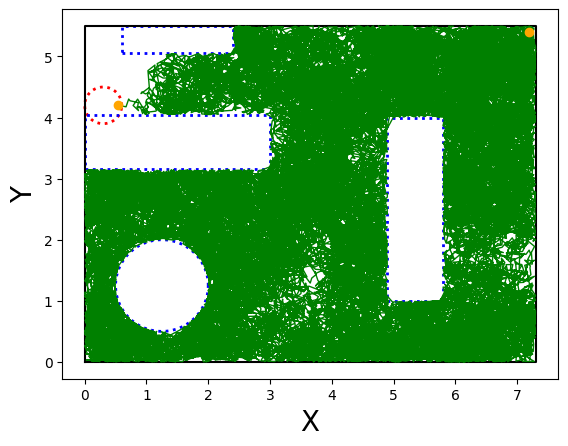

In [9]:
time_s1_p1 = simulate_s1_random_walking_path(0.3, 4.2)

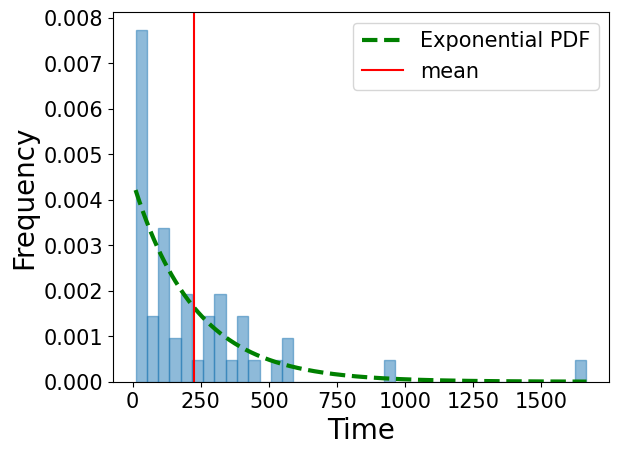

In [10]:
#plot a histogram of times
f_s1_p1 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s1_p1 = np.linspace(min(time_s1_p1), max(time_s1_p1), 500)
mu_s1_p1 = time_s1_p1.mean()
lam_vals_s1_p1 = 1/mu_s1_p1*np.ones(500)
plt.plot(x_vals_s1_p1, f_s1_p1(x_vals_s1_p1, lam_vals_s1_p1), color='g', linestyle='--', label='Exponential PDF', linewidth=3)
plt.axvline(mu_s1_p1, color='red', linestyle='-', label='mean')
plt.hist(time_s1_p1,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend(fontsize=15)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Strategy 1 with key point #2

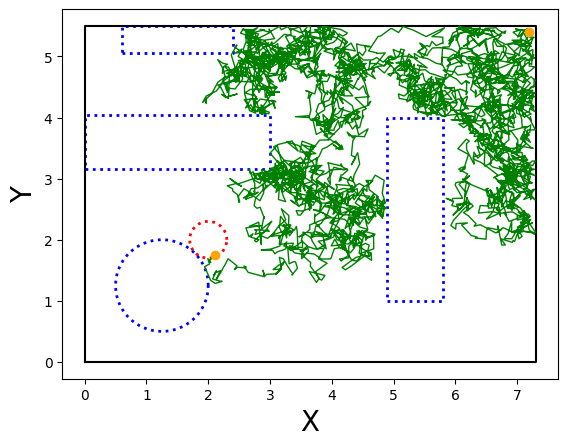

In [11]:
time_s1_p2 = simulate_s1_random_walking_path(2, 2)

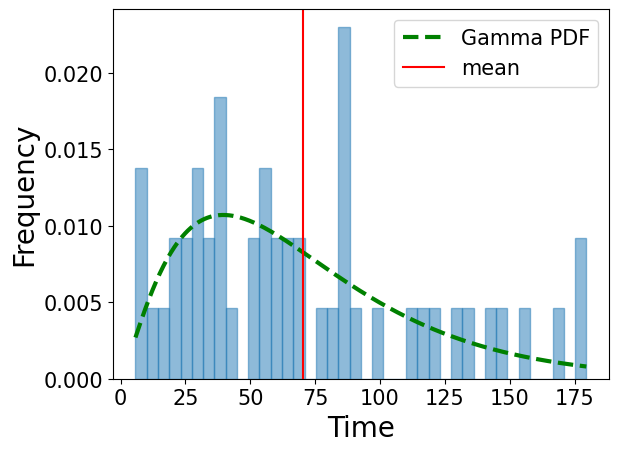

In [12]:
# plot a histogram of times
f_s1_p2 = lambda x, nu, lam: (lam/gamma(nu))*(lam*x)**(nu-1)*np.exp(-lam*x)
x_vals_s1_p2 = np.linspace(min(time_s1_p2), max(time_s1_p2), 500)
mu_s1_p2 = time_s1_p2.mean()
nu_vlas_s1_p2 = mu_s1_p2**2/time_s1_p2.var()*np.ones(500)
lam_vals_s1_p2 = nu_vlas_s1_p2/mu_s1_p2*np.ones(500)
plt.plot(x_vals_s1_p2, f_s1_p2(x_vals_s1_p2, nu_vlas_s1_p2,lam_vals_s1_p2), color='g', linestyle='--', label='Gamma PDF', linewidth=3)
plt.axvline(mu_s1_p2, color='red', linestyle='-', label='mean')
plt.hist(time_s1_p2,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend(fontsize=15)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Strategy 1 with key point #3

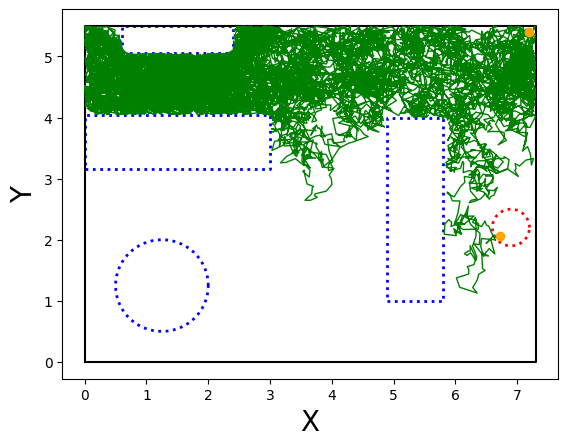

In [13]:
time_s1_p3 = simulate_s1_random_walking_path(6.9, 2.2)

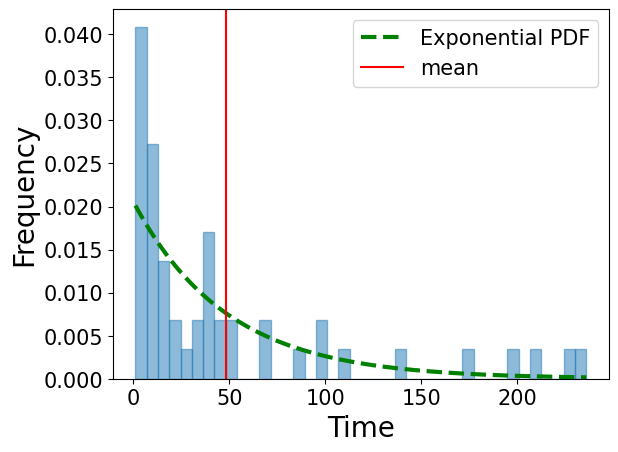

In [14]:
# plot a histogram of times
f_s1_p3 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s1_p3 = np.linspace(min(time_s1_p3), max(time_s1_p3), 500)
mu_s1_p3 = time_s1_p3.mean()
lam_vals_s1_p3 = 1/mu_s1_p3*np.ones(500)
plt.plot(x_vals_s1_p3, f_s1_p3(x_vals_s1_p3, lam_vals_s1_p3), color='g', linestyle='--', label='Exponential PDF', linewidth=3)
plt.axvline(mu_s1_p3, color='red', linestyle='-', label='mean')
plt.hist(time_s1_p3,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend(fontsize=15)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Strategy 1 with key point #4

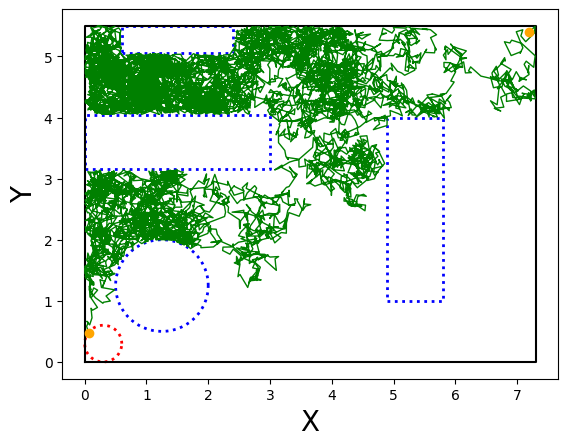

In [15]:
time_s1_p4 = simulate_s1_random_walking_path(0.3, 0.3)

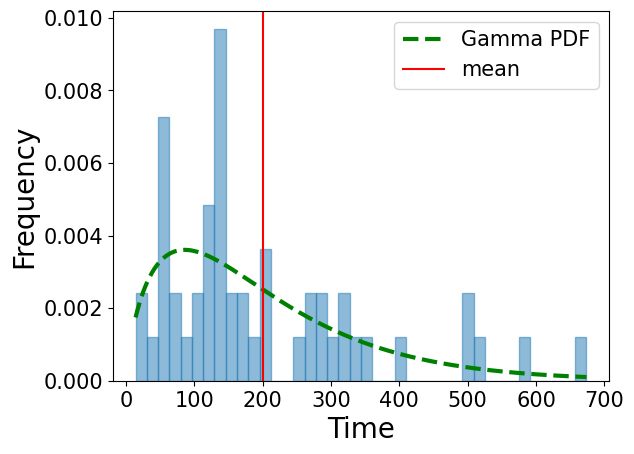

In [16]:
# plot a histogram of times
f_s1_p4 = lambda x, nu, lam: (lam/gamma(nu))*(lam*x)**(nu-1)*np.exp(-lam*x)
x_vals_s1_p4 = np.linspace(min(time_s1_p4), max(time_s1_p4), 500)
mu_s1_p4 = time_s1_p4.mean()
nu_vlas_s1_p4 = mu_s1_p4**2/time_s1_p4.var()*np.ones(500)
lam_vals_s1_p4 = nu_vlas_s1_p4/mu_s1_p4*np.ones(500)
plt.plot(x_vals_s1_p4, f_s1_p4(x_vals_s1_p4, nu_vlas_s1_p4,lam_vals_s1_p4), color='g', linestyle='--', label='Gamma PDF', linewidth=3)
plt.axvline(mu_s1_p4, color='red', linestyle='-', label='mean')
plt.hist(time_s1_p4,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend(fontsize=15)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Strategy 2 with key point #1

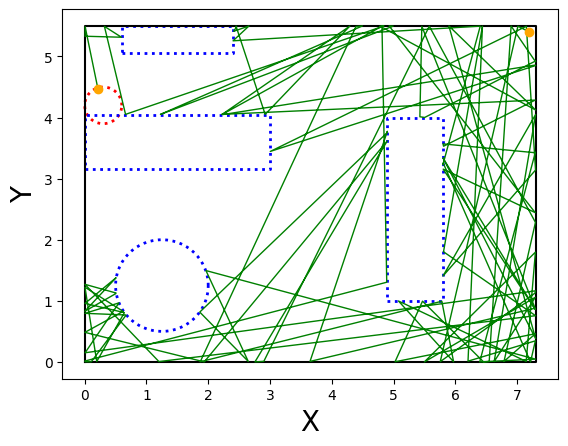

In [17]:
time_s2_p1 = simulate_s2_random_walking_path(0.3, 4.2)

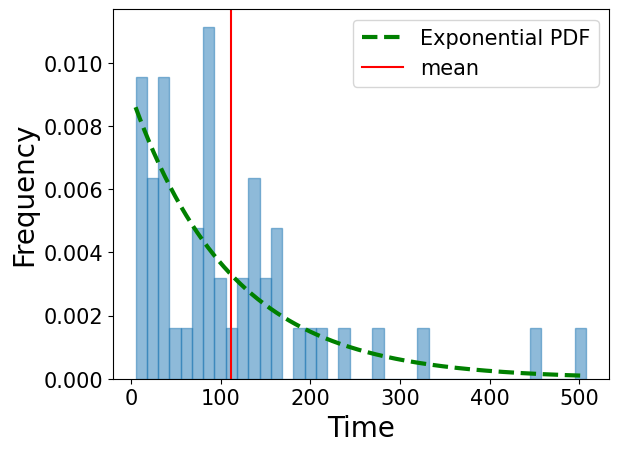

In [18]:
# plot a histogram of times
f_s2_p1 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s2_p1 = np.linspace(min(time_s2_p1), max(time_s2_p1), 500)
mu_s2_p1 = time_s2_p1.mean()
lam_vals_s2_p1 = 1/mu_s2_p1*np.ones(500)
plt.plot(x_vals_s2_p1, f_s2_p1(x_vals_s2_p1, lam_vals_s2_p1), color='g', linestyle='--', label='Exponential PDF', linewidth=3)
plt.axvline(mu_s2_p1, color='red', linestyle='-', label='mean')
plt.hist(time_s2_p1,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend(fontsize=15)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Strategy 2 with key point #2

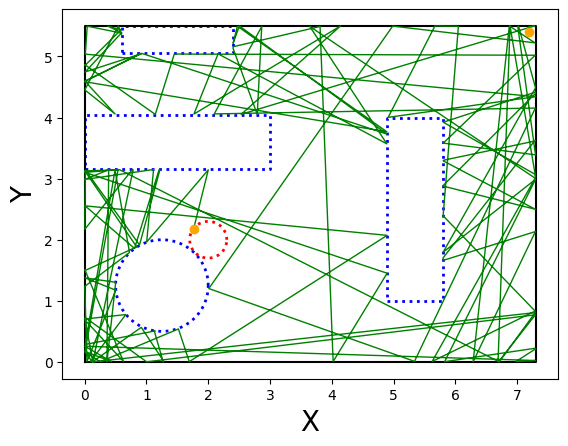

In [19]:
time_s2_p2 = simulate_s2_random_walking_path(2, 2)

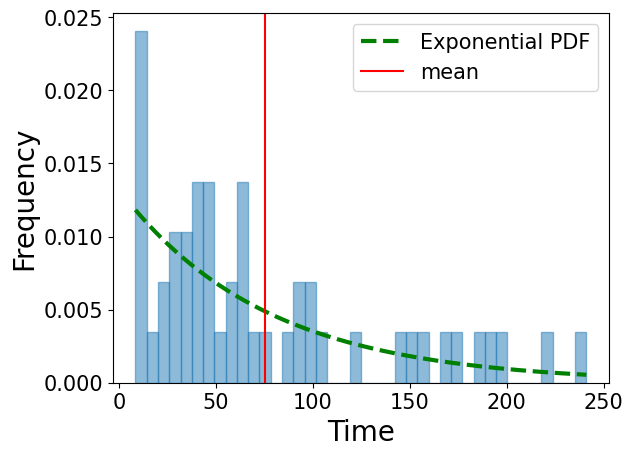

In [20]:
# plot a histogram of times
f_s2_p2 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s2_p2 = np.linspace(min(time_s2_p2), max(time_s2_p2), 500)
mu_s2_p2 = time_s2_p2.mean()
lam_vals_s2_p2 = 1/mu_s2_p2*np.ones(500)
plt.plot(x_vals_s2_p2, f_s2_p2(x_vals_s2_p2, lam_vals_s2_p2), color='g', linestyle='--', label='Exponential PDF', linewidth=3)
plt.axvline(mu_s2_p2, color='red', linestyle='-', label='mean')
plt.hist(time_s2_p2,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend(fontsize=15)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Strategy 2 with key point #3

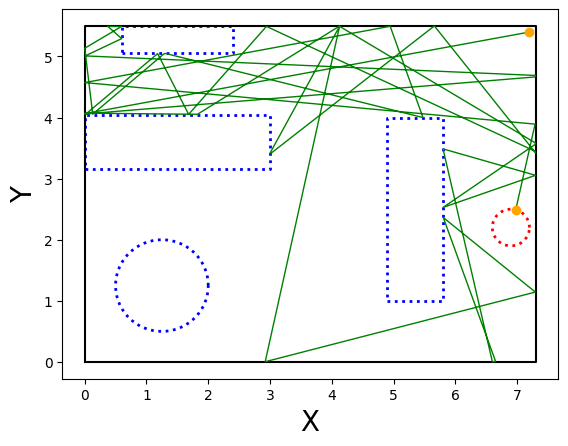

In [21]:
time_s2_p3 = simulate_s2_random_walking_path(6.9, 2.2)

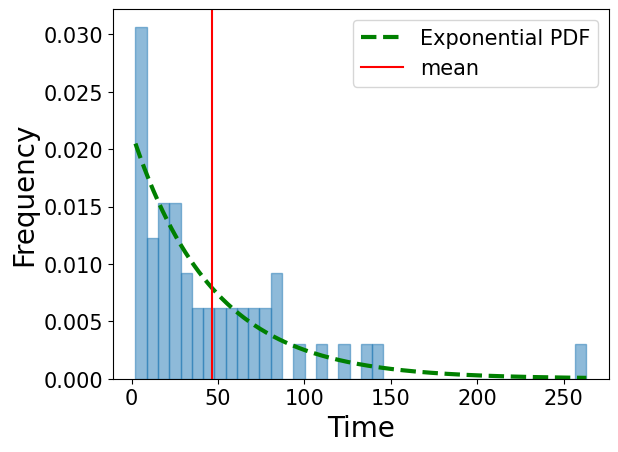

In [22]:
# plot a histogram of times
f_s2_p3 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s2_p3 = np.linspace(min(time_s2_p3), max(time_s2_p3), 500)
mu_s2_p3 = time_s2_p3.mean()
lam_vals_s2_p3 = 1/mu_s2_p3*np.ones(500)
plt.plot(x_vals_s2_p3, f_s2_p3(x_vals_s2_p3, lam_vals_s2_p3), color='g', linestyle='--', label='Exponential PDF', linewidth=3)
plt.axvline(mu_s2_p3, color='red', linestyle='-', label='mean')
plt.hist(time_s2_p3,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend(fontsize=15)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Strategy 2 with key point #4

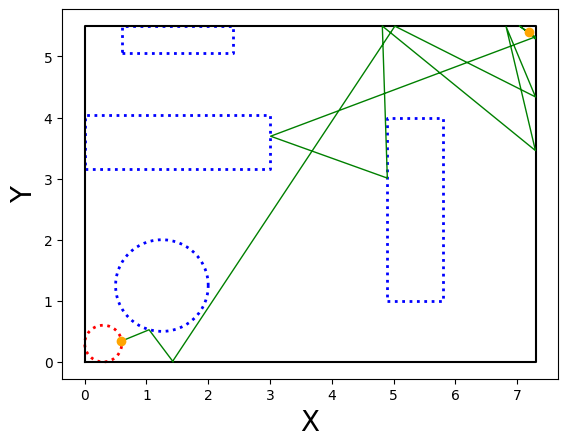

In [23]:
time_s2_p4 = simulate_s2_random_walking_path(0.3, 0.3)

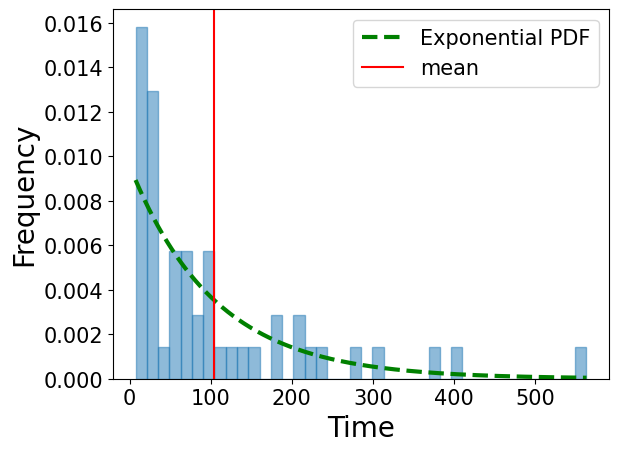

In [24]:
# plot a histogram of times
f_s2_p4 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s2_p4 = np.linspace(min(time_s2_p4), max(time_s2_p4), 500)
mu_s2_p4 = time_s2_p4.mean()
lam_vals_s2_p4 = 1/mu_s2_p4*np.ones(500)
plt.plot(x_vals_s2_p4, f_s2_p4(x_vals_s2_p4, lam_vals_s2_p4), color='g', linestyle='--', label='Exponential PDF', linewidth=3)
plt.axvline(mu_s2_p4, color='red', linestyle='-', label='mean')
plt.hist(time_s2_p4,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend(fontsize=15)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

## Comparing the statistic properties

In [25]:
dict = {
    'Time_S1_P1': time_s1_p1,
    'Time_S1_P2': time_s1_p2,
    'Time_S1_P3': time_s1_p3,
    'Time_S1_P4': time_s1_p4, 
    'Time_S2_P1': time_s2_p1,
    'Time_S2_P2': time_s2_p2,
    'Time_S2_P3': time_s2_p3,
    'Time_S2_P4': time_s2_p4, 
}

df = pd.DataFrame(dict).describe().T
df

,count,mean,std,min,25%,50%,75%,max
Time_S1_P1,50.0,226.0744,282.944400,11.08,48.4600,127.695,320.5000,1666.00
Time_S1_P2,50.0,70.4626,47.091558,5.76,33.0800,59.315,89.5700,179.54
Time_S1_P3,50.0,48.5158,63.054220,1.18,7.4600,20.810,50.8325,236.00
Time_S1_P4,50.0,200.9628,153.643812,14.03,108.9900,143.560,279.0925,673.82
Time_S2_P1,50.0,111.1310,104.353147,5.13,34.0950,86.605,145.8600,507.82
Time_S2_P2,50.0,75.5692,62.081089,8.52,30.8775,54.290,97.4575,241.06
Time_S2_P3,50.0,46.5110,48.569890,2.24,11.0125,31.835,69.4900,263.09
Time_S2_P4,50.0,104.5590,116.643362,7.19,24.6000,62.935,140.3100,563.55


### Box Plot

**Strategy 1**

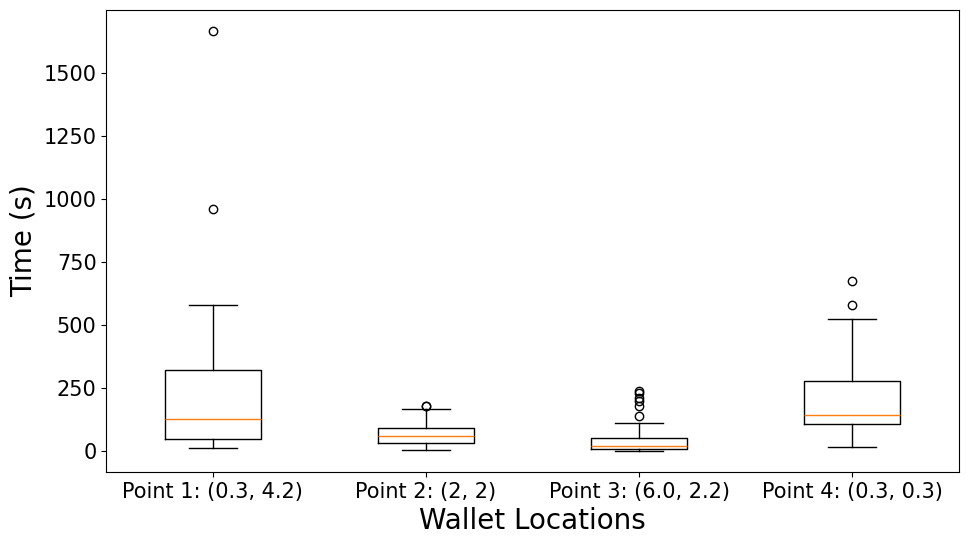

In [50]:
plt.figure(figsize=(11, 6))
plt.boxplot([time_s1_p1, time_s1_p2, time_s1_p3, time_s1_p4])
plt.xlabel("Wallet Locations", fontsize=20)
plt.ylabel("Time (s)", fontsize=20)
plt.xticks([1, 2, 3 , 4], ['Point 1: (0.3, 4.2)', 'Point 2: (2, 2)', 'Point 3: (6.0, 2.2)', 'Point 4: (0.3, 0.3)'], size = 15)
plt.yticks(size = 15)
plt.show()
# plt.xticks([1, 2, 3, 4], ['Pocket', 'Backpack', 'Desk', 'Car'])

**Strategy 2**

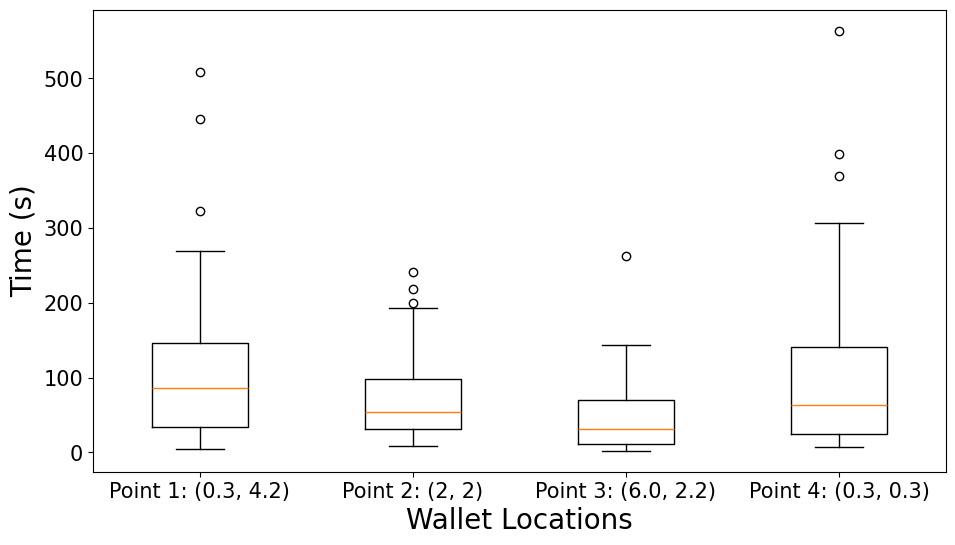

In [51]:
plt.figure(figsize=(11, 6))
plt.boxplot([time_s2_p1, time_s2_p2, time_s2_p3, time_s2_p4])
plt.xlabel("Wallet Locations", fontsize=20)
plt.ylabel("Time (s)", fontsize=20)
plt.xticks([1, 2, 3 , 4], ['Point 1: (0.3, 4.2)', 'Point 2: (2, 2)', 'Point 3: (6.0, 2.2)', 'Point 4: (0.3, 0.3)'], size = 15)
plt.yticks(size = 15)
plt.show()
plt.show()